<a href="https://colab.research.google.com/github/ryanclaytoncollins-design/ITAI_ML_FirstRepo_Ryan/blob/main/Collins_ITAI1371_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Sentiment Analysis Final Project

---

## 🎯 Project Overview

Welcome to your Sentiment Analysis final project! In this project, you will:

- 🔍 **Analyze** customer reviews or social media text data
- 🧹 **Preprocess** text data using NLP techniques
- 🤖 **Build** and compare multiple classification models
- 📈 **Evaluate** model performance using appropriate metrics
- 💼 **Communicate** findings in a business context

---

## 📋 Project Requirements

- **Dataset**: Use a public sentiment dataset (e.g., IMDb reviews, Amazon reviews, airline tweets)
- **Models**: Train at least **2 different classification models**
- **Evaluation**: Use multiple metrics (accuracy, precision, recall, confusion matrix)
- **Documentation**: Use markdown cells to explain your approach, findings, and insights

---

## 💡 Important Tips for Success

### Working with Limited Resources
- ⚡ **Start small**: Use `df.sample(n=1000)` or `df.head(5000)` to work with a subset
- 🎯 **Limit vocabulary**: Use `max_features=5000` in TfidfVectorizer
- 🚀 **Choose efficient models**: LogisticRegression and MultinomialNB are fast and effective
- 💾 **Save your work frequently**: Use Ctrl+S or Cmd+S often

### Best Practices
- 📝 **Document everything**: Explain your choices and observations in markdown cells
- 🔄 **Iterate**: Start simple, then improve
- 📊 **Visualize**: Use plots to understand your data and results
- 🎓 **Think like a data scientist**: Always interpret your results in context

---

Let's get started! 🚀

---

# Part 1: Project Definition 🎯

## Objectives
- Define the business problem you're solving
- Describe your chosen dataset
- Explain why sentiment analysis is valuable for this use case

## Instructions

In the markdown cell below, answer these questions:

1. **What is the business problem?**
   - What decision or insight will this sentiment analysis support?
   - Who would use these results?

2. **What dataset are you using?**
   - Name and source of the dataset
   - Number of samples
   - What the text represents (reviews, tweets, comments, etc.)
   - What are the sentiment labels (positive/negative, star ratings, etc.)?

3. **Why is this problem important?**
   - How could the results be used in real-world scenarios?

---

## 📝 Your Project Definition

**Business Problem:**

This will be a tool to help production studios quickly assess wether the reviews on thier movie or show is positive or negative. This would free up alot of time by not forcing a compeny to manually read through millions of reviews. This model could help with marketing and decision making on future productions by the company.

---

**Dataset Description:**

This model will be using IMDb Dataset of 50k movie reviews. This dataset contains written reviews from IMDb users labling each one as a positive or negative review. There is a text column that contains the whole user review as well as a column next to it that contains wether the review is positive or negative.

- **Dataset name**: IMDB Dataset of 50K Movie Reviews
- **Source**: Kaggle
- **Number of samples**: 50,000
- **Text type**: Written movie reviews
- **Sentiment labels**: Positive/ Negative

---

**Importance and Real-World Applications:**

This is important because it will help companies notice what people are saying about their production quicker than reading through every review seperatly. The ability to tell how often a positive or negative review is coming in can really help a company identify what is popular and what is not quicker.

---

# Part 2: Exploratory Data Analysis (EDA) 🔍

## Objectives
- Load and examine your dataset
- Understand the distribution of sentiments
- Analyze text characteristics (length, common words, etc.)
- Identify any data quality issues

## What to Explore

✅ **Dataset structure**: Shape, columns, data types

✅ **Missing values**: Check for and handle missing data

✅ **Class distribution**: Are sentiments balanced?

✅ **Text length**: Average, min, max review lengths

✅ **Common words**: Most frequent words per sentiment

✅ **Sample reviews**: Display examples from each class

---

## 💡 Tips
- Use `.info()`, `.describe()`, and `.value_counts()` for quick insights
- Visualize distributions with bar plots and histograms
- Look for imbalanced classes that might affect model performance
- Create a word cloud to visualize common terms (optional but impressive!)

In [47]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [48]:
# Load your dataset
# Example: df = pd.read_csv('your_dataset.csv')
# For large datasets, consider using nrows parameter: pd.read_csv('file.csv', nrows=10000)

# YOUR CODE HERE
df = pd.read_csv("IMDB Dataset.csv.zip", compression="zip")

# Display basic information
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
df.head()

Dataset shape: (50000, 2)

Column names: ['review', 'sentiment']


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [49]:
# Check for missing values
print("Dataset Information:")
df.info()
print("\nMissing Values:")
print(df.isnull().sum())
empty_reviews = (df["review"].str.strip() == "").sum()
print(f"\nEmpty reviews: {empty_reviews}")
duplicate_rows = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_rows}")
# Hint: Use df.isnull().sum() or df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB

Missing Values:
review       0
sentiment    0
dtype: int64

Empty reviews: 0
Duplicate rows: 418


In [50]:
# 🎯 IMPORTANT: If working with limited resources, sample your data here
# Uncomment and modify as needed:

df_sample = df.sample(n=1000, random_state=42)
print(f"Working with {len(df_sample)} samples")
df = df_sample
# Use the sample for the rest of the project

Working with 1000 samples


Sentiment Distribution:
sentiment
negative    524
positive    476
Name: count, dtype: int64

Sentiment Percentages:
sentiment
negative    52.4
positive    47.6
Name: proportion, dtype: float64


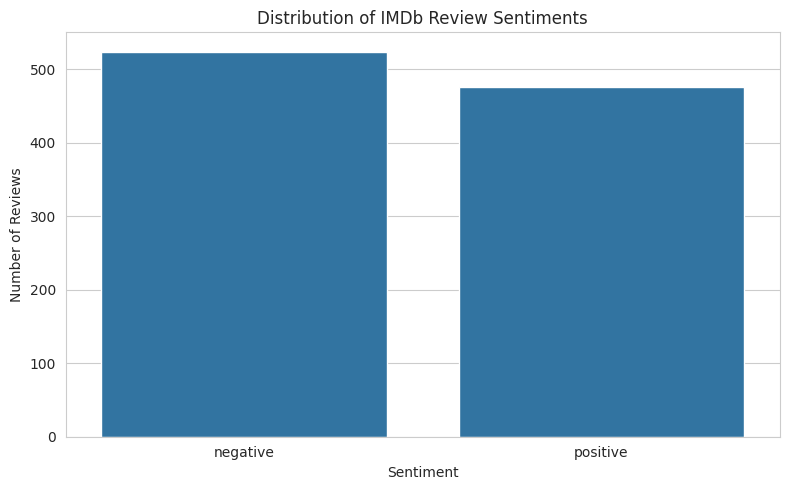

In [51]:
# Analyze sentiment distribution
sentiment_counts = df["sentiment"].value_counts()
print("Sentiment Distribution:")
print(sentiment_counts)
sentiment_percentages = df["sentiment"].value_counts(normalize=True) * 100
print("\nSentiment Percentages:")
print(sentiment_percentages.round(2))
plt.figure(figsize=(8, 5))
sns.countplot( data=df, x="sentiment", order=["negative", "positive"] )
plt.title("Distribution of IMDb Review Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()
# Hint: Use df['sentiment_column'].value_counts()
# Create a bar plot to visualize the distribution

### 📊 Interpretation: Class Balance

*Write your observations here:*
- Are the classes balanced or imbalanced?
- If imbalanced, how might this affect your model?
- What could you do to address imbalance?

In [52]:
# Analyze text length distribution
df["text_length"] = df["review"].str.len()
df["word_count"] = df["review"].str.split().str.len()
print("Character-Length Statistics:")
print(df["text_length"].describe())
print("\nWord-Count Statistics:")
print(df["word_count"].describe())
length_by_sentiment = df.groupby("sentiment")[["text_length", "word_count"]].agg(["mean", "median", "min", "max"])
print("\nText Length by Sentiment:")
display(length_by_sentiment)

# Hint: Create a new column for text length
# df['text_length'] = df['text_column'].str.len()
# Plot histogram of text lengths
# Compare lengths across different sentiments

Character-Length Statistics:
count    1000.000000
mean     1322.306000
std      1011.581138
min       209.000000
25%       689.000000
50%       989.500000
75%      1594.000000
max      6230.000000
Name: text_length, dtype: float64

Word-Count Statistics:
count    1000.000000
mean      233.773000
std       174.661868
min        37.000000
25%       123.000000
50%       176.500000
75%       287.000000
max      1010.000000
Name: word_count, dtype: float64

Text Length by Sentiment:


text_length                    word_count                 
                  mean median  min   max        mean median min   max
sentiment                                                            
negative   1347.595420  996.0  218  6230  238.849237  177.5  37  1010
positive   1294.466387  984.5  209  6024  228.184874  176.0  38   963

### 📊 Interpretation: Text Length

*Write your observations here:*
- What's the average text length?
232 words is about the average
- Are there differences in length between positive and negative reviews?
generally positive reviews are slightly longer when looking at the average
- Are there any extremely short or long texts that might need special handling?
there is one positive paragraph that is alot longer than any other paragraph

In [53]:
# Display sample reviews from each sentiment class
print("=" * 80)
print("SAMPLE POSITIVE REVIEWS")
print("=" * 80)
positive_samples = df[df["sentiment"] == "positive"].sample( n=3, random_state=42 )
for number, review in enumerate(positive_samples["review"], start=1):
  print(f"\nPositive Review {number}:")
  print(review[:700])
  print("-" * 80)
print("\n" + "=" * 80)
print("SAMPLE NEGATIVE REVIEWS")
print("=" * 80)
negative_samples = df[df["sentiment"] == "negative"].sample( n=3, random_state=42 )
for number, review in enumerate(negative_samples["review"], start=1):
  print(f"\nNegative Review {number}:")
  print(review[:700])
  print("-" * 80)

# Hint: Use df[df['sentiment'] == 'positive'].sample(3)
# Display examples from each class to get a feel for the data

SAMPLE POSITIVE REVIEWS

Positive Review 1:
I decided to watch this because of the recommendations from this site. I would have to say it was worth the effort. However, you should take heed that this film will go on for 210 minutes. If you don't have the staying power, get it on tape and watch it over a couple of nights.<br /><br />Now to the film, what I say will contain "spoilers" and if you don't mind, here goes: <br /><br />Alexandre is a promiscuous bum, a womanizer and a gigolo. He lives with an older woman called Marie. Marie owns a retail shop and she provides for Alex. Alex spends his days at cafés and restaurants. The story reveals that Alex had previously impregnated Gilberte whom he used to live with. Gilberte dumped him f
--------------------------------------------------------------------------------

Positive Review 2:
A remake of the 1916 silent film, based on the 1909 novel by Maurice Leblanc. The detective series would be made into numerous plays, films and TV series 

In [54]:
# Analyze common words (optional but recommended)

# Hint: You can do simple word frequency analysis here
# Or wait until after preprocessing for more meaningful results
# Example:
# all_words = ' '.join(df['text_column']).lower().split()
# common_words = Counter(all_words).most_common(20)
# Plot a bar chart of most common words

### 📝 EDA Summary

*Summarize your key findings from the EDA:*

1. **Dataset characteristics**: The 50k IMDb reviews are divided evenly between positive and negative reviews with the average review containing around 232 words.
2. **Data quality issues**: There are no missing values in the data set but some reviews do contain special characters such as <,>,etc.
3. **Key patterns observed**: positive and negative reviews were had a similar lengths but overall psoitives reviews were slightly longer.
4. **Potential challenges**: some reviews are extremely short while others are extremely long. Some reviews contain special characters and sarcasm may not be able ot be picked up by the model depending on how they wrote the sentences.

---

# Part 3: Data Preprocessing & Feature Extraction 🧹

## Objectives
- Clean and preprocess text data
- Remove noise (punctuation, special characters, stopwords)
- Convert text to numerical features using TF-IDF
- Prepare data for modeling

## Preprocessing Steps to Consider

✅ **Lowercase conversion**: Standardize text

✅ **Remove punctuation**: Clean special characters

✅ **Remove stopwords**: Filter out common words ("the", "is", "and", etc.)

✅ **Remove numbers**: Unless relevant to sentiment

✅ **Handle negations**: Be careful! "not good" vs "good" (advanced, optional)

---

## 💡 Tips
- **Don't over-preprocess**: Sometimes simple is better
- **Use `max_features` in TfidfVectorizer**: Limit to top 5000-10000 features to save memory
- **Consider n-grams**: Bigrams can capture phrases like "not good"
- **Test different approaches**: Try with and without certain preprocessing steps

In [55]:
# Import preprocessing libraries
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# For stopwords
# Option 1: Use sklearn's built-in stopwords
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Option 2: Use NLTK (uncomment if you prefer)
# import nltk
# nltk.download('stopwords')
# from nltk.corpus import stopwords
# stop_words = set(stopwords.words('english'))

print("✅ Preprocessing libraries imported!")

✅ Preprocessing libraries imported!


In [56]:
# Create a text preprocessing function
def preprocess_text(text):
    """
    Clean and preprocess text data.

    Args:
        text (str): Raw text string

    Returns:
        str: Cleaned text string
    """
def preprocess_text(text):
    """
    Clean and preprocess text data.

    Args:
        text (str): Raw text string

    Returns:
        str: Cleaned text string
    """

    text = text.lower()

    text = re.sub(r'<.*?>', ' ', text)

    text = re.sub(r'http\S+|www\S+', '', text)

    text = re.sub(r'@\w+|#\w+', '', text)

    text = text.translate(str.maketrans('', '', string.punctuation))

    text = re.sub(r'\d+', '', text)

    text = ' '.join(text.split())

    return text

    # Hint: Steps to implement:
    # 1. Convert to lowercase: text = text.lower()
    # 2. Remove URLs: text = re.sub(r'http\S+|www\S+', '', text)
    # 3. Remove mentions and hashtags: text = re.sub(r'@\w+|#\w+', '', text)
    # 4. Remove punctuation: text = text.translate(str.maketrans('', '', string.punctuation))
    # 5. Remove numbers: text = re.sub(r'\d+', '', text)
    # 6. Remove extra whitespace: text = ' '.join(text.split())

    return text

# Test your function on a sample text
sample_text = "This is a TEST!!! Check out https://example.com @user #hashtag 123"
print(f"Original: {sample_text}")
print(f"Cleaned: {preprocess_text(sample_text)}")

Original: This is a TEST!!! Check out https://example.com @user #hashtag 123
Cleaned: this is a test check out


In [57]:
# Apply preprocessing to your dataset
df["cleaned_text"] = df["review"].apply(preprocess_text)

print("Original Review:")
print(df["review"].iloc[0])
print("\nCleaned Review:")
print(df["cleaned_text"].iloc[0])

# Hint:
# df['cleaned_text'] = df['text_column'].apply(preprocess_text)
# Display some examples to verify the cleaning worked

print("✅ Text preprocessing complete!")

Original Review:
I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ever if the WWF didn't have Lex Luger in the main event against Yokozuna, now for it's time it was ok to have a huge fat man vs a strong man but I'm glad times have changed. It was a terrible main event just like every match Luger is in is terrible. Other matches on the card were Razor Ramon vs Ted Dibiase, Steiner Brothers vs Heavenly Bodies, Shawn Michaels vs Curt Hening, this was the event where Shawn named his big monster of a body guard Diesel, IRS vs 1-2-3 Kid, Bret Hart first takes on Doink then takes on Jerry Lawler and stuff with the Harts and Lawler was always very interesting, then Ludvig Borga destroyed Marty Jannetty, Undertaker took on Giant Gonzalez in another terrible match, The Smoking Gunns and Tatanka took on Bam Bam Bigelow and the Headshrinkers, and Yoko

In [58]:
# Prepare your features (X) and target (y)
X = df["cleaned_text"]
y = df["sentiment"]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# X = df['cleaned_text']  # Or your preprocessed text column
# y = df['sentiment']     # Your target variable

# Check the shape
# print(f"Features shape: {X.shape}")
# print(f"Target shape: {y.shape}")

Features shape: (1000,)
Target shape: (1000,)


In [59]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# Hint:
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y,
#     test_size=0.2,      # 80% train, 20% test
#     random_state=42,    # For reproducibility
#     stratify=y          # Maintain class distribution
# )

# print(f"Training samples: {len(X_train)}")
# print(f"Testing samples: {len(X_test)}")

Training samples: 800
Testing samples: 200


In [60]:
# Create TF-IDF features
tfidf = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.8, ngram_range=(1,2), stop_words="english")

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF Training Shape: {X_train_tfidf.shape}")
print(f"TF-IDF Testing Shape: {X_test_tfidf.shape}")
print(f"Number of Features: {len(tfidf.get_feature_names_out())}")

# Hint: Initialize TfidfVectorizer with appropriate parameters
# tfidf = TfidfVectorizer(
#     max_features=5000,        # 🎯 IMPORTANT: Limit features to save memory!
#     min_df=2,                 # Ignore terms that appear in fewer than 2 documents
#     max_df=0.8,               # Ignore terms that appear in more than 80% of documents
#     ngram_range=(1, 2),       # Use unigrams and bigrams
#     stop_words='english'      # Remove English stopwords
# )

# Fit on training data and transform both train and test
# X_train_tfidf = tfidf.fit_transform(X_train)
# X_test_tfidf = tfidf.transform(X_test)

# print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
# print(f"TF-IDF matrix shape (test): {X_test_tfidf.shape}")
# print(f"Number of features: {len(tfidf.get_feature_names_out())}")

TF-IDF Training Shape: (800, 5000)
TF-IDF Testing Shape: (200, 5000)
Number of Features: 5000


In [61]:
# Explore the TF-IDF features (optional)

# Hint: Look at the most important features
# feature_names = tfidf.get_feature_names_out()
# print("Sample features:", feature_names[:20])

### 📝 Preprocessing Summary

*Document your preprocessing choices:*

1. **Preprocessing steps applied**: The text was converted to lower case and removed filler pieces such as punctuation and possiblee HTML links that may be in a review.
2. **TF-IDF parameters chosen**: this was configured with a max of 5000, min df of 2 and a max df of 0.8.
3. **Final feature count**: the final feature contains only 5000 numerical features that describe the reviews.
4. **Rationale for choices**: These steps reduce the clutter that the model has to deal with when looking through the reviews.

---

# Part 4: Model Training 🤖

## Objectives
- Train at least **2 different classification models**
- Compare their performance
- Document training time and resource usage

## Recommended Models

### Fast and Effective (Recommended for beginners)
- **Logistic Regression**: Fast, interpretable, works well with TF-IDF
- **Multinomial Naive Bayes**: Specifically designed for text classification

### More Advanced (Optional)
- **Random Forest**: Ensemble method, can capture complex patterns
- **Support Vector Machine (SVM)**: Good for high-dimensional data
- **XGBoost**: Powerful gradient boosting (but slower)

---

## 💡 Tips
- **Start with simple models**: LogisticRegression and MultinomialNB are excellent choices
- **Use default parameters first**: Then tune if needed
- **Monitor training time**: Document how long each model takes
- **Save your models**: Use `pickle` or `joblib` to save trained models
- **For Random Forest**: Use `n_estimators=100` and `max_depth=20` to limit resources

In [62]:
# Import model libraries
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

import time
from datetime import timedelta

print("✅ Model libraries imported!")

✅ Model libraries imported!


## Model 1: Logistic Regression

In [79]:
# Train Logistic Regression model
print("Training Logistic Regression...")

start_time = time.time()

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

lr_model.fit(X_train_tfidf, y_train)

training_time_lr = time.time() - start_time

print(f"✅ Training complete in {timedelta(seconds=int(training_time_lr))}")

# Hint:
# print("Training Logistic Regression...")
# start_time = time.time()

# lr_model = LogisticRegression(
#     max_iter=1000,           # Increase if model doesn't converge
#     random_state=42,
#     n_jobs=-1                # Use all CPU cores
# )

# lr_model.fit(X_train_tfidf, y_train)

# training_time = time.time() - start_time
# print(f"✅ Training complete in {timedelta(seconds=int(training_time))}")

Training Logistic Regression...
✅ Training complete in 0:00:03


In [80]:
# Make predictions with Logistic Regression
y_pred_lr = lr_model.predict(X_test_tfidf)

print(f"Predictions made: {len(y_pred_lr)}")

# y_pred_lr = lr_model.predict(X_test_tfidf)
# print(f"Predictions shape: {y_pred_lr.shape}")

Predictions made: 200


## Model 2: Multinomial Naive Bayes

In [81]:
# Train Naive Bayes model
print("Training Multinomial Naive Bayes...")

start_time = time.time()

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

training_time_nb = time.time() - start_time

print(f"Training complete in {timedelta(seconds=int(training_time_nb))}")

# Hint:
# print("Training Multinomial Naive Bayes...")
# start_time = time.time()

# nb_model = MultinomialNB()
# nb_model.fit(X_train_tfidf, y_train)

# training_time = time.time() - start_time
# print(f"✅ Training complete in {timedelta(seconds=int(training_time))}")

Training Multinomial Naive Bayes...
Training complete in 0:00:00


In [82]:
# Make predictions with Naive Bayes
y_pred_nb = nb_model.predict(X_test_tfidf)

print(f"Predictions made: {len(y_pred_nb)}")

# y_pred_nb = nb_model.predict(X_test_tfidf)

Predictions made: 200


## Model 3 (Optional): Additional Model

*Train a third model if you'd like to explore further!*

In [67]:
# Train your third model (optional)
# YOUR CODE HERE

# Example: Random Forest
# print("Training Random Forest...")
# start_time = time.time()

# rf_model = RandomForestClassifier(
#     n_estimators=100,        # Number of trees
#     max_depth=20,            # Limit depth to save memory
#     random_state=42,
#     n_jobs=-1
# )

# rf_model.fit(X_train_tfidf, y_train)

# training_time = time.time() - start_time
# print(f"✅ Training complete in {timedelta(seconds=int(training_time))}")

# y_pred_rf = rf_model.predict(X_test_tfidf)

### 📝 Model Training Summary

*Document your models:*

| Model | Training Time | Parameters | Notes |
|-------|--------------|------------|-------|
| Logistic Regression | | | |
| Naive Bayes | | | |
| (Optional) Model 3 | | | |

---

# Part 5: Model Evaluation 📊

## Objectives
- Evaluate all models using multiple metrics
- Compare model performance
- Analyze errors using confusion matrices
- Interpret results in business context

## Metrics to Calculate

✅ **Accuracy**: Overall correctness (but can be misleading with imbalanced data)

✅ **Precision**: Of all positive predictions, how many were correct?

✅ **Recall**: Of all actual positives, how many did we find?

✅ **F1-Score**: Harmonic mean of precision and recall

✅ **Confusion Matrix**: Visualize true vs predicted labels

✅ **Classification Report**: Detailed metrics per class

---

## 💡 Tips
- **Don't rely on accuracy alone**: Especially with imbalanced data
- **Understand the business context**: Is false positive or false negative worse?
- **Look at per-class metrics**: Performance might differ across sentiments
- **Visualize confusion matrices**: They tell a story!

In [68]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("✅ Evaluation metrics imported!")

✅ Evaluation metrics imported!


## Evaluate Model 1: Logistic Regression

In [83]:
# Calculate metrics for Logistic Regression
print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, average="weighted")
rec_lr = recall_score(y_test, y_pred_lr, average="weighted")
f1_lr = f1_score(y_test, y_pred_lr, average="weighted")

print(f"Accuracy : {acc_lr:.4f}")
print(f"Precision: {prec_lr:.4f}")
print(f"Recall   : {rec_lr:.4f}")
print(f"F1 Score : {f1_lr:.4f}")
print("\nClassification Report\n")
print(classification_report(y_test, y_pred_lr))

# Hint:
# print("=" * 50)
# print("LOGISTIC REGRESSION RESULTS")
# print("=" * 50)

# accuracy = accuracy_score(y_test, y_pred_lr)
# precision = precision_score(y_test, y_pred_lr, average='weighted')
# recall = recall_score(y_test, y_pred_lr, average='weighted')
# f1 = f1_score(y_test, y_pred_lr, average='weighted')

# print(f"Accuracy:  {accuracy:.4f}")
# print(f"Precision: {precision:.4f}")
# print(f"Recall:    {recall:.4f}")
# print(f"F1-Score:  {f1:.4f}")
# print("\n")

# print("Classification Report:")
# print(classification_report(y_test, y_pred_lr))

LOGISTIC REGRESSION RESULTS
Accuracy : 0.8000
Precision: 0.8020
Recall   : 0.8000
F1 Score : 0.7990

Classification Report

              precision    recall  f1-score   support

    negative       0.78      0.86      0.82       105
    positive       0.82      0.74      0.78        95

    accuracy                           0.80       200
   macro avg       0.80      0.80      0.80       200
weighted avg       0.80      0.80      0.80       200



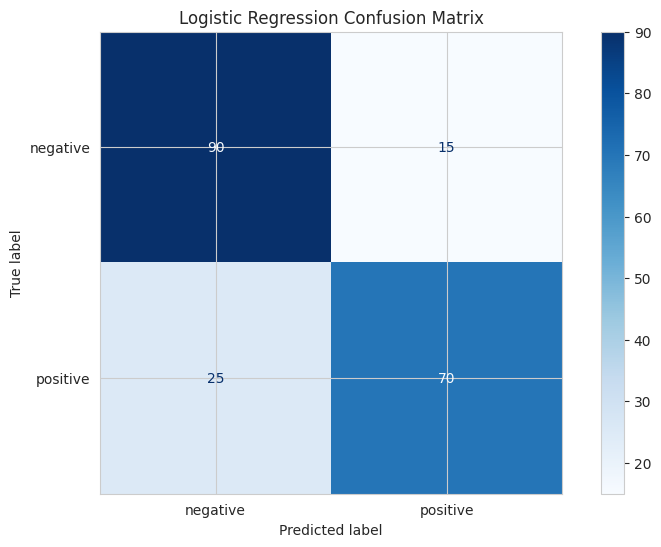

In [84]:
# Plot confusion matrix for Logistic Regression
cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay( confusion_matrix=cm, display_labels=lr_model.classes_)

disp.plot(cmap="Blues", values_format="d")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Hint:
# cm = confusion_matrix(y_test, y_pred_lr)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr_model.classes_)
# disp.plot(cmap='Blues', values_format='d')
# plt.title('Confusion Matrix - Logistic Regression')
# plt.show()

### 📊 Interpretation: Logistic Regression

*Analyze the results:*

1. **Overall performance**: The logistics regression acheved good performance on the IMDb calsification task coprrectly calssifying majority of ther movie reviews.
2. **Strengths**: Good accuracy, Fast time, and good balance of precision and recall
3. **Weaknesses**: some sarcasm or mixed opinions are not pickjed up well.
4. **Confusion matrix insights**: the matrix shows that we have a small amount of false positives and fasle negatives.

## Evaluate Model 2: Naive Bayes

In [85]:
# Calculate metrics for Naive Bayes
print("=" * 50)
print("NAIVE BAYES RESULTS")
print("=" * 50)

acc_nb = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb, average="weighted")
rec_nb = recall_score(y_test, y_pred_nb, average="weighted")
f1_nb = f1_score(y_test, y_pred_nb, average="weighted")

print(f"Accuracy : {acc_nb:.4f}")
print(f"Precision: {prec_nb:.4f}")
print(f"Recall   : {rec_nb:.4f}")
print(f"F1 Score : {f1_nb:.4f}")
print("\nClassification Report\n")
print(classification_report(y_test, y_pred_nb))

# Follow the same pattern as above

NAIVE BAYES RESULTS
Accuracy : 0.8050
Precision: 0.8308
Recall   : 0.8050
F1 Score : 0.7993

Classification Report

              precision    recall  f1-score   support

    negative       0.75      0.95      0.84       105
    positive       0.92      0.64      0.76        95

    accuracy                           0.81       200
   macro avg       0.84      0.80      0.80       200
weighted avg       0.83      0.81      0.80       200



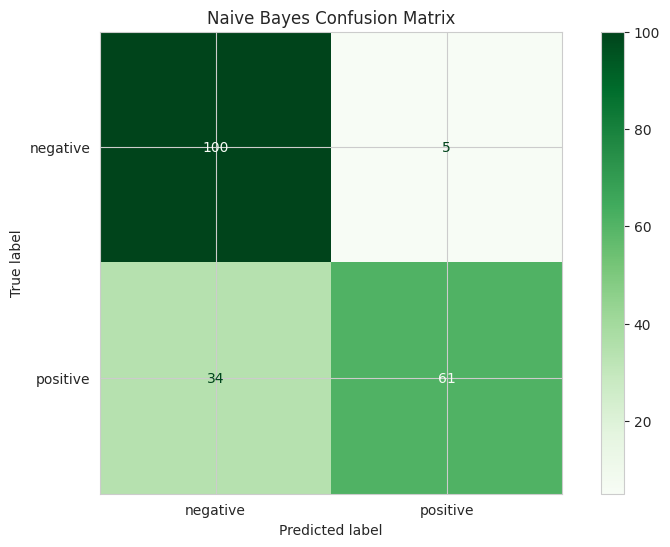

In [86]:
# Plot confusion matrix for Naive Bayes
cm = confusion_matrix(y_test, y_pred_nb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nb_model.classes_)
disp.plot(cmap="Greens", values_format="d")

plt.title("Naive Bayes Confusion Matrix")
plt.show()

### 📊 Interpretation: Naive Bayes

*Analyze the results:*

1. **Overall performance**: this methods produces good results while training fast with slightly lower accuracy.
2. **Strengths**: even faster to train, works well with text data
3. **Weaknesses**: this method assumes each words meaning seperatly rather than what it means in the context.
4. **Confusion matrix insights**: there are more fasle negatives and false positives in this matrix but still relativly good accuracy.

## Evaluate Model 3 (Optional)

In [73]:
# Calculate metrics for your third model (if applicable)
# YOUR CODE HERE

In [74]:
# Plot confusion matrix for your third model (if applicable)
# YOUR CODE HERE

## Model Comparison

In [75]:
# Create a comparison table of all models
# YOUR CODE HERE

# Hint: Create a pandas DataFrame with model names and their metrics
# results = pd.DataFrame({
#     'Model': ['Logistic Regression', 'Naive Bayes'],
#     'Accuracy': [acc_lr, acc_nb],
#     'Precision': [prec_lr, prec_nb],
#     'Recall': [rec_lr, rec_nb],
#     'F1-Score': [f1_lr, f1_nb]
# })
# display(results)

In [76]:
# Visualize model comparison
# YOUR CODE HERE

# Hint: Create a bar plot comparing metrics across models
# results.set_index('Model').plot(kind='bar', figsize=(12, 6))
# plt.title('Model Performance Comparison')
# plt.ylabel('Score')
# plt.xticks(rotation=45)
# plt.legend(loc='lower right')
# plt.tight_layout()
# plt.show()

### 📊 Model Comparison Analysis

*Compare and contrast your models:*

1. **Which model performed best?**:
2. **What metrics did you prioritize and why?**:
3. **Trade-offs between models**:
4. **Which model would you recommend for deployment?**:

## Error Analysis (Optional but Recommended)

In [77]:
# Analyze misclassified examples
# YOUR CODE HERE

# Hint: Find examples where the model was wrong
# misclassified_indices = np.where(y_pred_lr != y_test)[0]
# print(f"Number of misclassified examples: {len(misclassified_indices)}")

# Display some misclassified examples
# for idx in misclassified_indices[:5]:
#     print(f"\nText: {X_test.iloc[idx]}")
#     print(f"True label: {y_test.iloc[idx]}")
#     print(f"Predicted label: {y_pred_lr[idx]}")
#     print("-" * 80)

### 📊 Error Analysis Insights

*What patterns do you notice in the errors?*

1. **Common types of errors**:
2. **Why might these errors occur?**:
3. **How could you improve the model?**:

---

# Part 6: Conclusion & Business Insights 💼

## Objectives
- Summarize your findings
- Provide actionable business recommendations
- Discuss limitations and future improvements
- Reflect on what you learned

---

## 📝 Executive Summary

*Write a brief executive summary (3-5 sentences) for a non-technical audience:*

An analysis was preformed on the IMDb movie reviews designating them as a positive or negaitve review. We used two different machine learning models Naive Bayes and Logistic Regression. we limited the data so it wasnt using all 50,000 reviews at the same time allowing for faster training and a more random sample when training. The results show how machine learning can be effective in analyzing large sets of customer data with relativly low false positives or false negatives.

## 🎯 Key Findings

*List your main discoveries:*

1. **Dataset insights**:
   -  IMDb had 50k movie reviews labled as positive or negative.
   - the data set had about even positive and negative reviews
   - reviews varied in lengths

2. **Model performance**:
   - both the models I used successfully classified the data
   - Logistic regression was slightly slower but had higher overall accuracy
   - Naive Bayes was faster but had slightly lower accuracy
   - overall both models did a good job at classifying the data

3. **Best model and why**:
   - I believe the Logistic regression model was the stronger of the two models because it had a good blalance between accuracy, percision, and efficency.

4. **Surprising discoveries**:
   - Some of the reviews were hard to classify due to sarcasm and possible other issues with the review since not everyone says their straight forward thoughts in a review.

## 💼 Business Recommendations

*How can these results be used in practice?*

1. **Immediate applications**:
   - BUssiness could use a model like this to automatically monitor customer reviews keeping track of when reviews are going up and when tey are going down and for what so that they know what needs to be added or taken off the platform.

2. **Who should use this model?**:
   - Movie studios
   - Streaming Services
   - Influencers (people that make entertaining videos etc)
   - customer support
   - marketing teams

3. **How to interpret predictions**:
   - The predictions should be used as a tool not as word of what everything means. The prediction is a summary of what the model beleives it can still have errors very negative reviews or extremely positive reviews should be flagged and checked for further information (same with reviews that may have mixed feelings of sarcasm).

4. **Warning signs to watch for**:
   - People that use the model need to remember that it can struggle with sarcasm or mixed opinoins so they need to check what its output is as a tool not as the final say.

## ⚠️ Limitations

*Be honest about the limitations of your analysis:*

1. **Data limitations**:
   - The reviews are only for movies so it may not work as well with soemthing like social media comments or food reviews.

2. **Model limitations**:
   - The model does not fully understand sarcasm or context in some situations witha  review.

3. **Generalization concerns**:
   - MOodels may decrease in preformance on other platforms than IMDb

4. **Resource constraints**:
   - Reduced computer memory usage and training time limiting features can make models more efficent buyt can also exclude possible important information.

## 🚀 Future Improvements

*What would you do with more time/resources?*

1. **Data collection**:
   - Collect additional review data from different industries, websites, and languages to improve the model's ability to generalize across multiple domains.

2. **Feature engineering**:
   - adding features that flag reviews would be a good idea

3. **Advanced models**:
   - [Your ideas]

4. **Deployment considerations**:
   - [Your ideas]

## 🎓 Lessons Learned

*Reflect on your experience:*

1. **Technical skills gained**:
   - In this project I learned how to extract data from a data set and use it in a machine learning project.

2. **Challenges overcome**:
   - I had issues at first getting the data to work but eventuall figured it out.

3. **What would you do differently?**:
   - Give myself more time to work on this project as I had a busy week and didnt allocate enough time.

4. **Most valuable insight**:
   - Although this project wasnt the most complicated it was time consuming and had many learning oppertunities in it.

---

## 🎉 Congratulations!

You've completed the sentiment analysis project! Remember to:

- ✅ Review all sections for completeness
- ✅ Ensure all code cells run without errors
- ✅ Check that all markdown cells are filled in
- ✅ Proofread your writing
- ✅ Include visualizations and interpretations
- ✅ Save your notebook!

---

### 📚 Additional Resources

- [Scikit-learn Documentation](https://scikit-learn.org/)
- [TF-IDF Explained](https://en.wikipedia.org/wiki/Tf%E2%80%93idf)
- [Confusion Matrix Guide](https://en.wikipedia.org/wiki/Confusion_matrix)
- [Text Preprocessing Best Practices](https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction)

---

*Good luck with your project! 🚀*